In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

materials = [
    "Paper Wrap","Cardboard Box","Corrugated Board","Kraft Paper","Glass Bottle",
    "Aluminum Can","Steel Container","Wood Crate","Plastic Container","Bioplastic",
    "Cotton Bag","Jute Bag","Bamboo Fiber","Hemp Fiber","Palm Leaf","Bagasse",
    "Mushroom Packaging","Seaweed Packaging","Corn Starch Pack","Cellulose Film",
    "Bio Foam","Wood Pulp","Glass Jar","Tin Container","Foil Wrap","Paperboard",
    "Rigid Box","Flexible Packaging","Cloth Wrap","Leather Wrap","Fiberboard",
    "Hardboard","Softwood Box","Plywood Box","Metal Drum","Plastic Barrel",
    "HDPE Container","LDPE Wrap","PET Bottle","PVC Container","Rubber Packaging",
    "Silicone Wrap","Organic Fiber","Textile Packaging","Recycled Paper",
    "Composite Packaging","Eco Wrap","Reusable Container","Refillable Bottle",
    "Biodegradable Film","Plant-based Plastic","Organic Polymer","Natural Fiber",
    "Compressed Paper","Wax Coated Paper","Greaseproof Paper",
    "Thermoformed Plastic","Molded Fiber","Air Cushion Packaging",
    "Bubble Wrap","Foam Insert","Corrugated Tray","Honeycomb Board",
    "Wood Wool","Straw Packaging","Coconut Fiber","Banana Fiber",
    "Areca Leaf","Rice Husk Packaging"
]

n = 1200

df = pd.DataFrame({
    "material_name": np.random.choice(materials, n),
    "strength": np.random.randint(1, 4, n),
    "weight_capacity": np.random.randint(1, 30, n),
    "biodegradability_score": np.random.randint(3, 10, n),
    "recyclability_percentage": np.random.randint(40, 100, n)
})

df["cost"] = df["strength"]*12 + df["weight_capacity"]*2 + np.random.randint(5,25,n)
df["co2_score"] = 12 - df["biodegradability_score"] + np.random.randint(0,3,n)

df.head()

,material_name,strength,weight_capacity,biodegradability_score,recyclability_percentage,cost,co2_score
0,Organic Polymer,2,2,9,58,39,5
1,Palm Leaf,1,21,9,42,60,4
2,Foam Insert,1,25,6,49,77,7
3,Bio Foam,2,20,4,79,81,9
4,Tin Container,3,11,9,86,67,3


In [4]:
df.to_csv("ecopackai_materials.csv", index=False)

In [5]:
print(df.shape)

(1200, 7)


In [6]:
from db_connection import get_connection
import pandas as pd

conn = get_connection()

query = "SELECT * FROM eco_packaging_materials LIMIT 200;"
df = pd.read_sql(query, conn)

print(df.head())

conn.close()

   material_id    material_name  strength  weight_capacity  cost  \
0         2401  Organic Polymer         2                2  39.0   
1         2402        Palm Leaf         1               21  60.0   
2         2403      Foam Insert         1               25  77.0   
3         2404         Bio Foam         2               20  81.0   
4         2405    Tin Container         3               11  67.0   

   biodegradability_score  co2_score  recyclability_percentage  
0                       9        5.0                        58  
1                       9        4.0                        42  
2                       6        7.0                        49  
3                       4        9.0                        79  
4                       9        3.0                        86  


/var/folders/j1/yr_vsj450wd8k7zbg8cksldh0000gp/T/ipykernel_33565/2908017515.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [7]:
df.describe()

,material_id,strength,weight_capacity,cost,biodegradability_score,co2_score,recyclability_percentage
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2500.500000,1.990000,15.740000,70.290000,5.995000,6.945000,71.065000
std,57.879185,0.832687,8.192557,19.681277,2.048403,2.199126,18.239357
min,2401.000000,1.000000,1.000000,22.000000,3.000000,3.000000,40.000000
25%,2450.750000,1.000000,8.750000,58.000000,4.000000,5.000000,55.000000
50%,2500.500000,2.000000,17.000000,71.000000,6.000000,7.000000,71.000000
75%,2550.250000,3.000000,23.000000,86.000000,8.000000,8.250000,87.250000
max,2600.000000,3.000000,29.000000,116.000000,9.000000,11.000000,99.000000


In [8]:
df.to_csv("ecopackai_materials_frozen.csv", index=False)

In [9]:
df = pd.read_csv("ecopackai_materials_frozen.csv")

In [10]:
df['eco_score'] = (
    df['recyclability_percentage'] +
    df['biodegradability_score']
) / 2

df['cost_norm'] = (
    df['cost'] - df['cost'].min()
) / (df['cost'].max() - df['cost'].min())

df['co2_norm'] = (
    df['co2_score'] - df['co2_score'].min()
) / (df['co2_score'].max() - df['co2_score'].min())

df['suitability'] = (
    df['eco_score'] +
    df['cost_norm'] +
    df['co2_norm']
)

df['final_score'] = (
    0.4 * df['cost_norm'] +
    0.4 * df['co2_norm'] +
    0.2 * df['suitability']
)

In [11]:
from sklearn.model_selection import train_test_split

X = df[['strength', 'weight_capacity', 'eco_score', 'cost_norm', 'co2_norm']]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 0.11430953010599657
RMSE: 0.1407901545142116
R2: 0.9941526072171987


In [14]:
top = df.sort_values(by='final_score', ascending=False)

top[['material_name', 'final_score']].head(10)

,material_name,final_score
126,Flexible Packaging,11.233511
157,Paper Wrap,11.185638
122,Corrugated Tray,11.184574
165,Wax Coated Paper,11.146277
198,Reusable Container,11.112766
151,Corrugated Board,11.079787
150,Cardboard Box,11.070745
125,Flexible Packaging,11.026596
195,Bubble Wrap,11.015426
141,Tin Container,10.946277


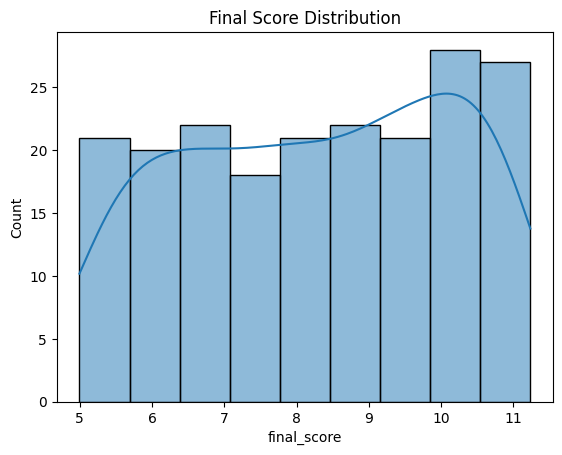

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['final_score'], kde=True)
plt.title("Final Score Distribution")
plt.show()

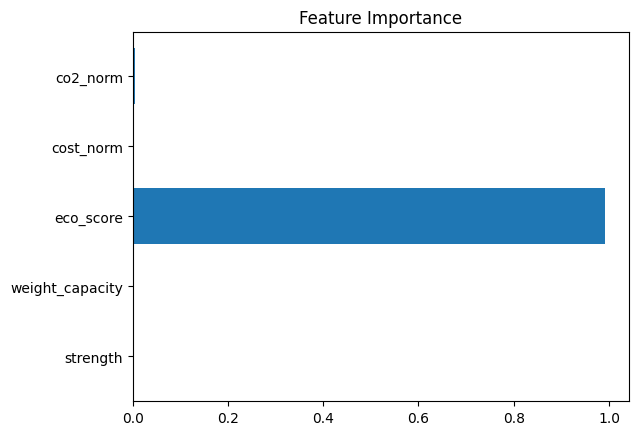

In [16]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [17]:
def recommend_material(strength, weight_capacity, biodegradability, recyclability):
    
    # create eco score
    eco_score = (recyclability + biodegradability) / 2
    
    # normalize (use dataset values)
    cost_norm = 0.5   # placeholder
    co2_norm = 0.5    # placeholder
    
    input_data = [[strength, weight_capacity, eco_score, cost_norm, co2_norm]]
    
    prediction = model.predict(input_data)[0]
    
    return prediction

In [18]:
score = recommend_material(3, 20, 8, 85)
print("Predicted Score:", score)

Predicted Score: 10.095212


In [19]:
def recommend_best_material(strength, weight_capacity, biodegradability, recyclability):
    
    eco_score = (recyclability + biodegradability) / 2
    
    # compute score for all materials
    df['input_score'] = (
        0.4 * df['cost_norm'] +
        0.4 * df['co2_norm'] +
        0.2 * eco_score
    )
    
    best = df.sort_values(by='input_score', ascending=False).iloc[0]
    
    return best['material_name'], best['input_score']

In [20]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']